# Phân Tích Customer Churn — Telco
## Báo cáo Machine Learning · Telco Customer Churn Dataset

---

> **Sinh viên:** *Phạm Ngọc Thế Kiều*  
> **MSSV:** *2321003593*     
> **Dataset:** [Telco Customer Churn — Kaggle](https://www.kaggle.com/blastchar/telco-customer-churn)

---

##  Tóm tắt bài toán

Một công ty viễn thông muốn **dự đoán khách hàng nào có khả năng rời bỏ dịch vụ (churn)** trong kỳ tới,  
nhằm triển khai can thiệp giữ chân có mục tiêu trước khi quyết định rời bỏ xảy ra.

**Định nghĩa Churn:** Khách hàng ngừng sử dụng dịch vụ trong kỳ quan sát (`Churn = "Yes"`).

##  Mục tiêu phân tích

| # | Mục tiêu |
|---|---------|
| 1 | Hiểu cấu trúc, phân bố và chất lượng dữ liệu |
| 2 | Khám phá các yếu tố liên quan đến hành vi churn (EDA) |
| 3 | Xây dựng và so sánh các mô hình phân loại theo quy trình ML chuẩn |
| 4 | Đánh giá bằng Recall, AUC — không chỉ Accuracy |
| 5 | Rút ra insight và đề xuất hành động kinh doanh cụ thể |

##  Ý nghĩa kinh doanh

Chi phí giữ chân khách hàng cũ thấp hơn 5–7 lần so với thu hút khách mới.  
Một mô hình dự đoán tốt cho phép đội ngũ chăm sóc khách hàng **chủ động tiếp cận đúng người, đúng thời điểm** —  
trước khi họ quyết định rời đi.


## 1. Import thư viện <a id='1-import'></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

## 2. Đọc dữ liệu <a id='2-load'></a>

Dataset sử dụng là **Telco Customer Churn** — dữ liệu khách hàng của một công ty viễn thông giả lập,  
bao gồm thông tin nhân khẩu học, dịch vụ đăng ký, hợp đồng, thanh toán và nhãn churn.


In [2]:
data = pd.read_csv("Telco-Customer-Churn.csv")
print(f"Kích thước dataset: {data.shape[0]:,} dòng × {data.shape[1]} cột")
display(data.head(5))


Kích thước dataset: 7,043 dòng × 21 cột


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Cấu trúc & chất lượng dữ liệu <a id='3-understand'></a>

Kiểm tra kiểu dữ liệu, giá trị thiếu, và một vấn đề đặc trưng của dataset này:  
cột `TotalCharges` được import dưới dạng `object` vì một số dòng chứa chuỗi khoảng trắng `" "`  
thay vì số thực — tương ứng với các khách hàng có `tenure = 0` (chưa phát sinh hóa đơn).


In [3]:
print("=== Thông tin tổng quan ===")
data.info()

print("\n=== Giá trị thiếu (NaN) theo cột ===")
print(data.isna().sum())

print("\n=== Số dòng TotalCharges = ' ' (khoảng trắng) ===")
print((data["TotalCharges"] == " ").sum())

print("\n=== Dòng trùng lặp ===")
print(f"Số dòng trùng: {data.duplicated().sum()}")

print("\n=== Thống kê biến số ===")
display(data.describe())


=== Thông tin tổng quan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Phân bố biến mục tiêu `Churn` <a id='4-target'></a>

Trước khi bất kỳ bước xử lý nào, cần xác định mức độ mất cân bằng lớp (class imbalance) —  
điều này ảnh hưởng trực tiếp đến lựa chọn metric đánh giá và chiến lược xử lý imbalance sau này.

> **Lưu ý:** Nếu dữ liệu mất cân bằng đáng kể, Accuracy trở nên vô nghĩa.  
> Một mô hình luôn đoán "Không churn" vẫn đạt ~74% accuracy — nhưng hoàn toàn vô dụng trong thực tế.  
> → Ưu tiên **Recall** (phát hiện đúng khách churn) và **ROC-AUC** làm metric chính.


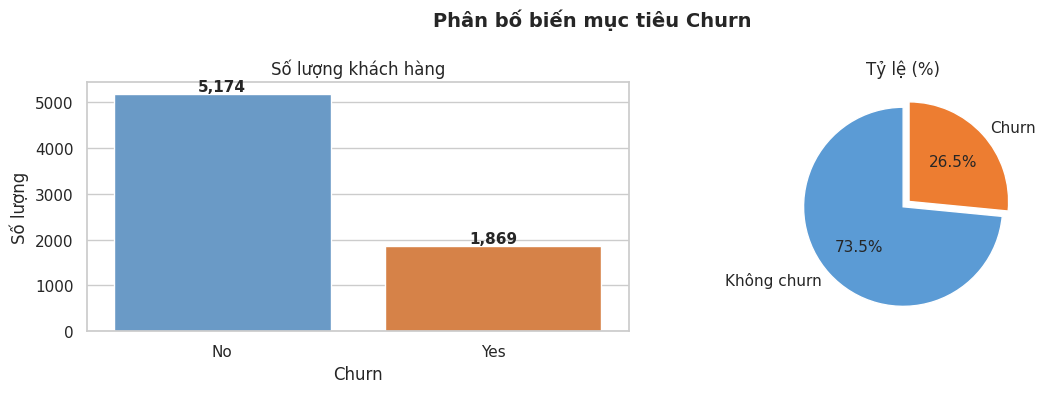


Phân bố: 5,174 Không churn (73.5%) | 1,869 Churn (26.5%)
Tỷ lệ imbalance: 2.8:1
→ Dữ liệu MẤT CÂN BẰNG — cần xử lý trước khi huấn luyện.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Phân bố biến mục tiêu Churn", fontsize=14, fontweight="bold")

churn_counts = data["Churn"].value_counts()

# Count plot
colors = ["#5B9BD5", "#ED7D31"]
sns.countplot(x="Churn", data=data, ax=axes[0], palette={"No": "#5B9BD5", "Yes": "#ED7D31"},
              order=["No", "Yes"])
axes[0].set_title("Số lượng khách hàng")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Số lượng")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():,.0f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=11, fontweight="bold")

# Pie chart
churn_counts.plot.pie(
    autopct="%1.1f%%", startangle=90, explode=(0, 0.08),
    colors=["#5B9BD5", "#ED7D31"], ax=axes[1],
    labels=["Không churn", "Churn"], textprops={"fontsize": 11}
)
axes[1].set_ylabel("")
axes[1].set_title("Tỷ lệ (%)")

plt.tight_layout()
plt.show()

imbalance_ratio = churn_counts["No"] / churn_counts["Yes"]
print(f"\nPhân bố: {churn_counts['No']:,} Không churn ({churn_counts['No']/len(data)*100:.1f}%) "
      f"| {churn_counts['Yes']:,} Churn ({churn_counts['Yes']/len(data)*100:.1f}%)")
print(f"Tỷ lệ imbalance: {imbalance_ratio:.1f}:1")
print("→ Dữ liệu MẤT CÂN BẰNG — cần xử lý trước khi huấn luyện.")


## 5. Làm sạch dữ liệu <a id='5-clean'></a>

**Vấn đề phát hiện:** Cột `TotalCharges` chứa chuỗi khoảng trắng `" "` ở 11 dòng —  
đây là các khách hàng có `tenure = 0` (mới đăng ký, chưa phát sinh hóa đơn).  
Số lượng rất nhỏ (<0.2% dataset) nên xóa an toàn mà không làm mất thông tin đáng kể.

**Quy trình làm sạch:**
1. Thay `" "` bằng `NaN`
2. Xóa các dòng có `NaN`


In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna(subset=["TotalCharges"])          # bỏ 11 dòng bị rỗng
data = data.drop(columns=["customerID"])             # bỏ mã khách hàng
# Kiểm tra kết quả
print(f"\nSố dòng sau làm sạch     : {len(data):,}")
print(f"Kiểu TotalCharges        : {data['TotalCharges'].dtype}")
print(f"Giá trị thiếu còn lại   : {data.isna().sum().sum()}")
print(f"Giá trị âm TotalCharges : {(data['TotalCharges'] < 0).sum()}")
print("\n✓ Dữ liệu sạch — sẵn sàng cho phân tích.")



Số dòng sau làm sạch     : 7,032
Kiểu TotalCharges        : float64
Giá trị thiếu còn lại   : 0
Giá trị âm TotalCharges : 0

✓ Dữ liệu sạch — sẵn sàng cho phân tích.


## 6. Phân tích Khám phá Dữ liệu (EDA) <a id='7-eda'></a>

EDA nhằm hiểu **mối quan hệ giữa từng đặc trưng và hành vi churn**.  
Kết quả EDA dẫn đường cho việc lựa chọn đặc trưng, giải thích mô hình, và đề xuất kinh doanh.

> **Lưu ý:** Biến `Tenure_Group` tạo ở bước này **chỉ dùng cho EDA** —  
> sẽ không đưa vào mô hình vì trùng thông tin với `tenure` (đã có trong features số).


### 6.1 Tạo nhóm thời gian gắn bó (`Tenure_Group`) — chỉ dùng cho EDA

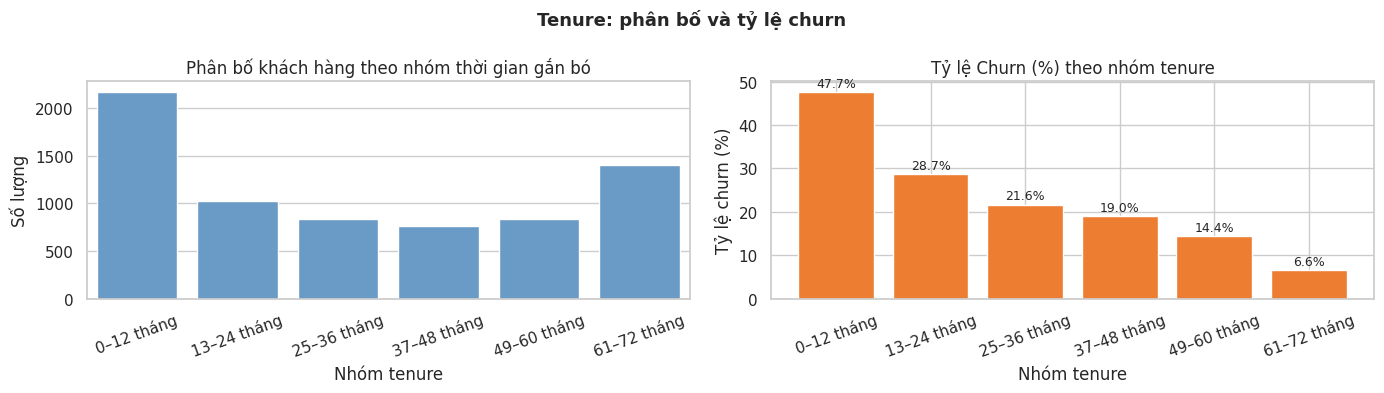

In [6]:
def tenure_to_group(t):
    if t <= 12:   return "0–12 tháng"
    elif t <= 24: return "13–24 tháng"
    elif t <= 36: return "25–36 tháng"
    elif t <= 48: return "37–48 tháng"
    elif t <= 60: return "49–60 tháng"
    else:         return "61–72 tháng"

tenure_order = ["0–12 tháng", "13–24 tháng", "25–36 tháng",
                "37–48 tháng", "49–60 tháng", "61–72 tháng"]

data["Tenure_Group"] = data["tenure"].apply(tenure_to_group)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Countplot tổng
sns.countplot(x="Tenure_Group", data=data, order=tenure_order,
              color="#5B9BD5", ax=axes[0])
axes[0].set_title("Phân bố khách hàng theo nhóm thời gian gắn bó")
axes[0].set_xlabel("Nhóm tenure"); axes[0].set_ylabel("Số lượng")
axes[0].tick_params(axis="x", rotation=20)

# Tỷ lệ churn theo tenure group
churn_rate = (data.groupby("Tenure_Group")["Churn"]
              .apply(lambda x: (x == "Yes").mean() * 100)
              .reindex(tenure_order))
axes[1].bar(tenure_order, churn_rate, color="#ED7D31")
axes[1].set_title("Tỷ lệ Churn (%) theo nhóm tenure")
axes[1].set_xlabel("Nhóm tenure"); axes[1].set_ylabel("Tỷ lệ churn (%)")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(churn_rate):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.suptitle("Tenure: phân bố và tỷ lệ churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 6.2 Churn theo các biến phân loại

Biểu đồ dưới trả lời câu hỏi: **nhóm nào trong từng biến có tỷ lệ churn cao hơn?**  
Trục x là giá trị của biến, màu sắc phân biệt `Churn = Yes/No`.


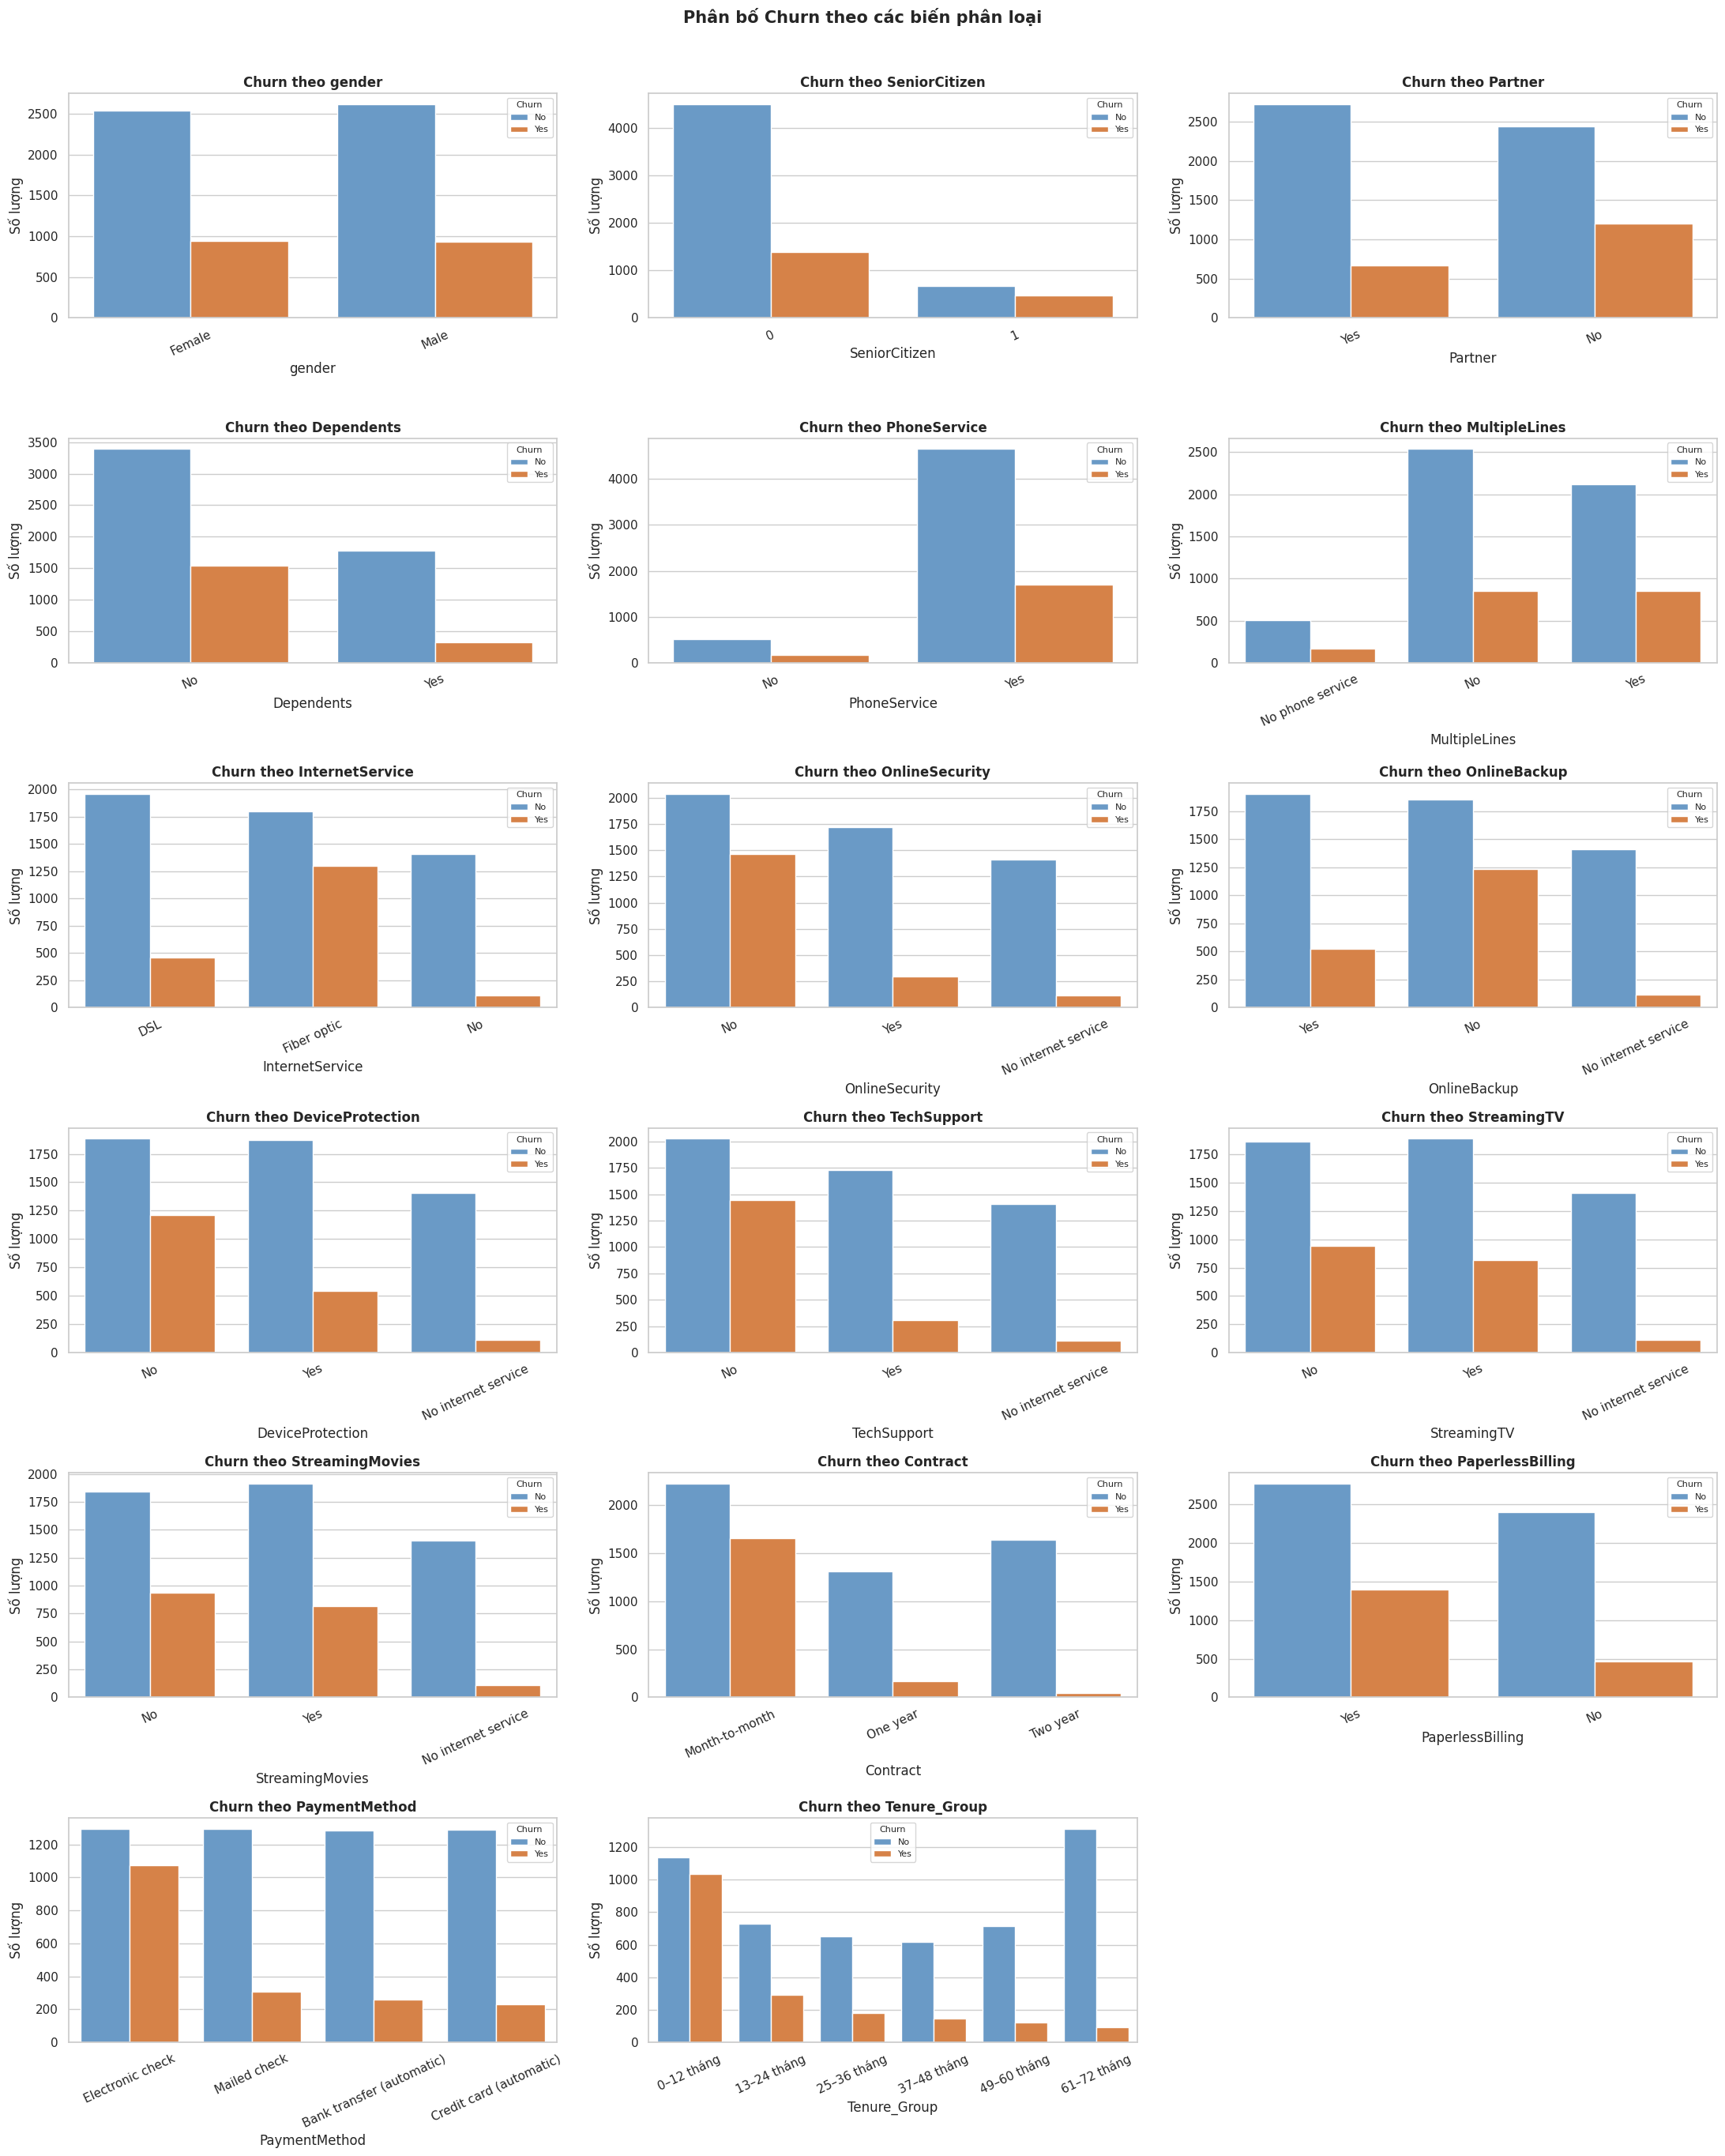

In [7]:
cat_eda_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "Tenure_Group"
]

nrows = (len(cat_eda_cols) + 2) // 3
fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(22, nrows * 4.5))
axes_flat = axes.flatten()

for idx, col in enumerate(cat_eda_cols):
    ax = axes_flat[idx]
    order_x = tenure_order if col == "Tenure_Group" else None
    sns.countplot(x=col, hue="Churn", data=data, ax=ax,
                  order=order_x, palette={"No": "#5B9BD5", "Yes": "#ED7D31"})
    ax.set_title(f"Churn theo {col}", fontweight="bold")
    ax.set_xlabel(col); ax.set_ylabel("Số lượng")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Churn", fontsize=8, title_fontsize=8)

# Ẩn ô thừa
for j in range(len(cat_eda_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Phân bố Churn theo các biến phân loại", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Nhận xét EDA biến phân loại:**

- **Contract**: Nhóm `Month-to-month` chiếm tuyệt đại đa số trong số khách hàng churn.  
  Hợp đồng ngắn hạn có rào cản rời bỏ thấp → **rủi ro churn cao nhất**.
- **Tenure_Group**: Nhóm `0–12 tháng` có tỷ lệ churn cao nhất, giảm dần theo thời gian gắn bó —  
  khách hàng mới chưa có sự gắn kết đủ mạnh.
- **InternetService**: Khách dùng `Fiber optic` churn nhiều hơn `DSL` đáng kể —  
  có thể phản ánh kỳ vọng cao hơn hoặc mức phí cao hơn chưa tương xứng với chất lượng cảm nhận.
- **OnlineSecurity, TechSupport, DeviceProtection**: Khách hàng **không** đăng ký các dịch vụ hỗ trợ  
  này churn nhiều hơn rõ rệt — gợi ý các dịch vụ add-on đóng vai trò giữ chân.
- **PaperlessBilling**: Khách dùng hóa đơn điện tử churn nhiều hơn — tương quan với nhóm Fiber optic.
- **PaymentMethod**: `Electronic check` gắn với tỷ lệ churn cao hơn so với các phương thức tự động.
- **Gender**: Không có sự khác biệt đáng kể — biến này ít giá trị dự báo.


### 6.3 Phân bố biến số theo Churn — Boxplot & KDE

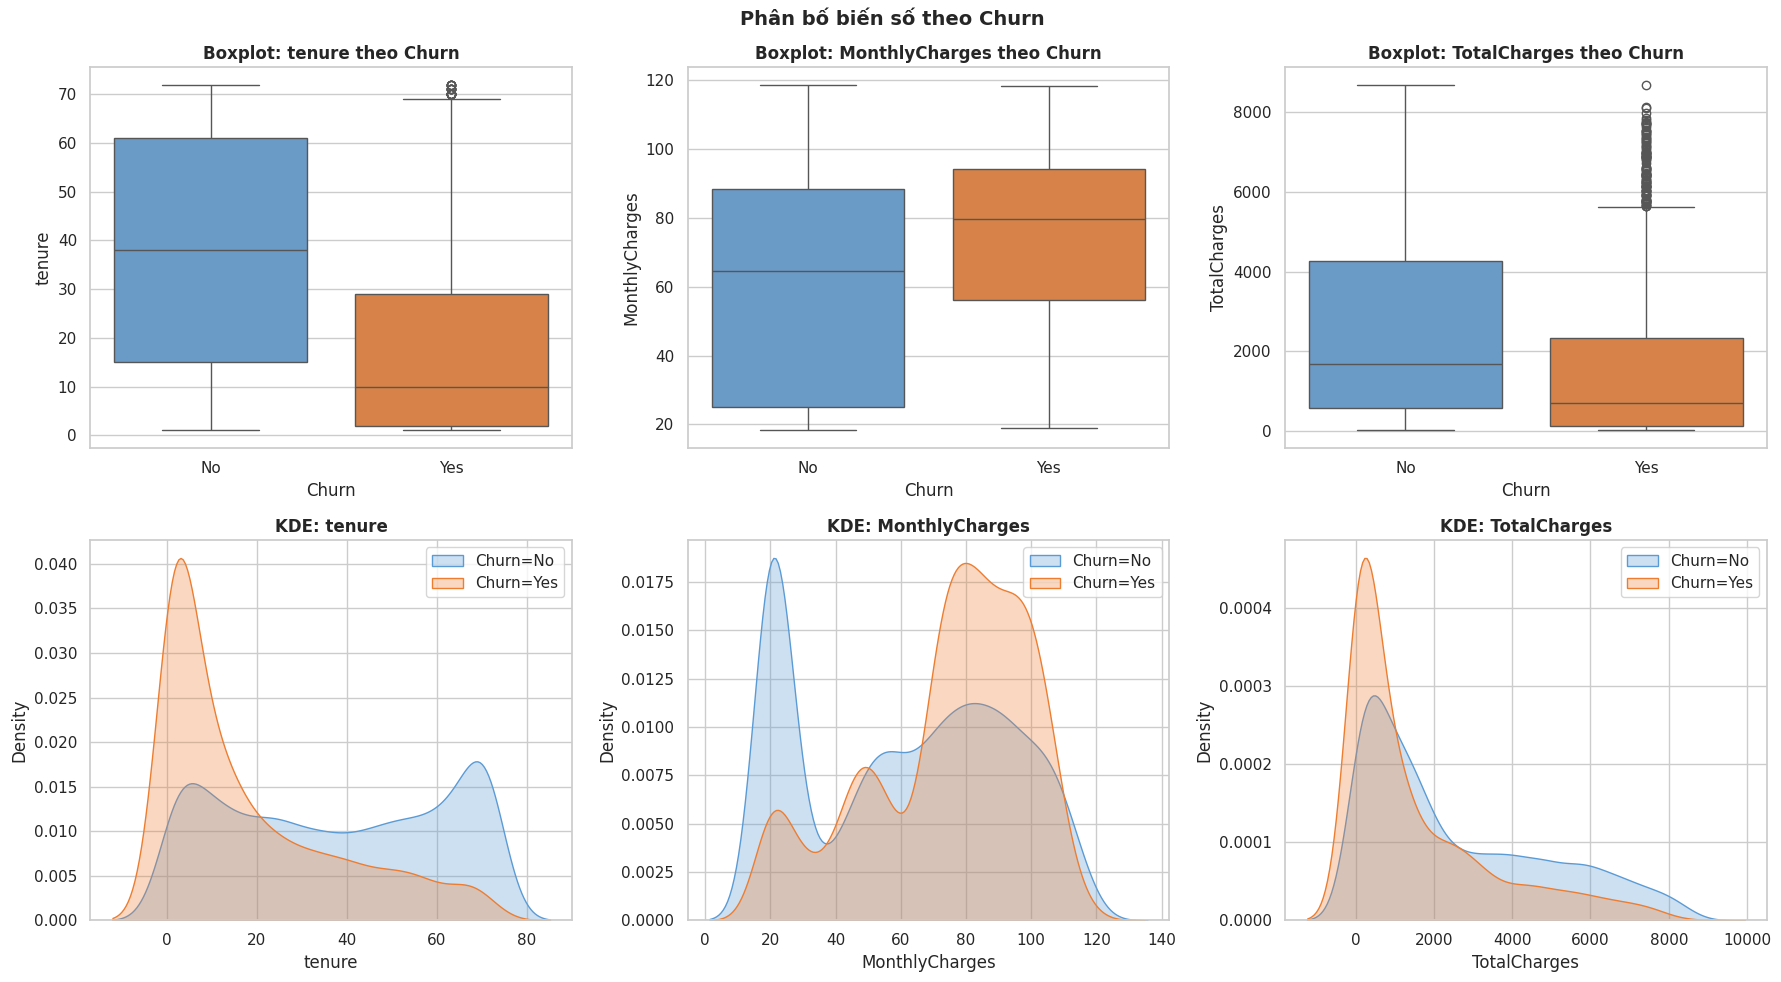

In [8]:
num_eda_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for j, col in enumerate(num_eda_cols):
    # Boxplot
    sns.boxplot(x="Churn", y=col, data=data, ax=axes[0][j],
                order=["No", "Yes"], palette={"No": "#5B9BD5", "Yes": "#ED7D31"})
    axes[0][j].set_title(f"Boxplot: {col} theo Churn", fontweight="bold")
    axes[0][j].set_xlabel("Churn"); axes[0][j].set_ylabel(col)

    # KDE
    for churn_val, color in [("No", "#5B9BD5"), ("Yes", "#ED7D31")]:
        subset = data[data["Churn"] == churn_val][col]
        sns.kdeplot(subset, ax=axes[1][j], label=f"Churn={churn_val}",
                    color=color, fill=True, alpha=0.3)
    axes[1][j].set_title(f"KDE: {col}", fontweight="bold")
    axes[1][j].set_xlabel(col); axes[1][j].legend()

plt.suptitle("Phân bố biến số theo Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Nhận xét biến số:**

- **tenure**: Khách churn có tenure trung bình thấp hơn rõ rệt (KDE lệch trái).  
  Xác nhận: **khách hàng mới có nguy cơ churn cao hơn đáng kể**.
- **MonthlyCharges**: Khách churn có phí hàng tháng cao hơn — nhất quán với việc họ  
  thường dùng Fiber optic hoặc nhiều dịch vụ add-on nhưng rời đi vì không thỏa mãn với giá trị nhận được.
- **TotalCharges**: Khách churn có tổng phí thấp hơn dù phí tháng cao hơn —  
  vì tenure thấp nên chưa tích lũy đủ. Đây là hệ quả tự nhiên của tenure thấp.

> **Lưu ý multicollinearity**: `TotalCharges ≈ tenure × MonthlyCharges` — ba biến này tương quan cao.  
> Mô hình cây (Decision Tree, Random Forest) xử lý tốt điều này; với Logistic Regression cần lưu ý.


### 6.4 Phí trung bình theo nhóm tenure & Churn

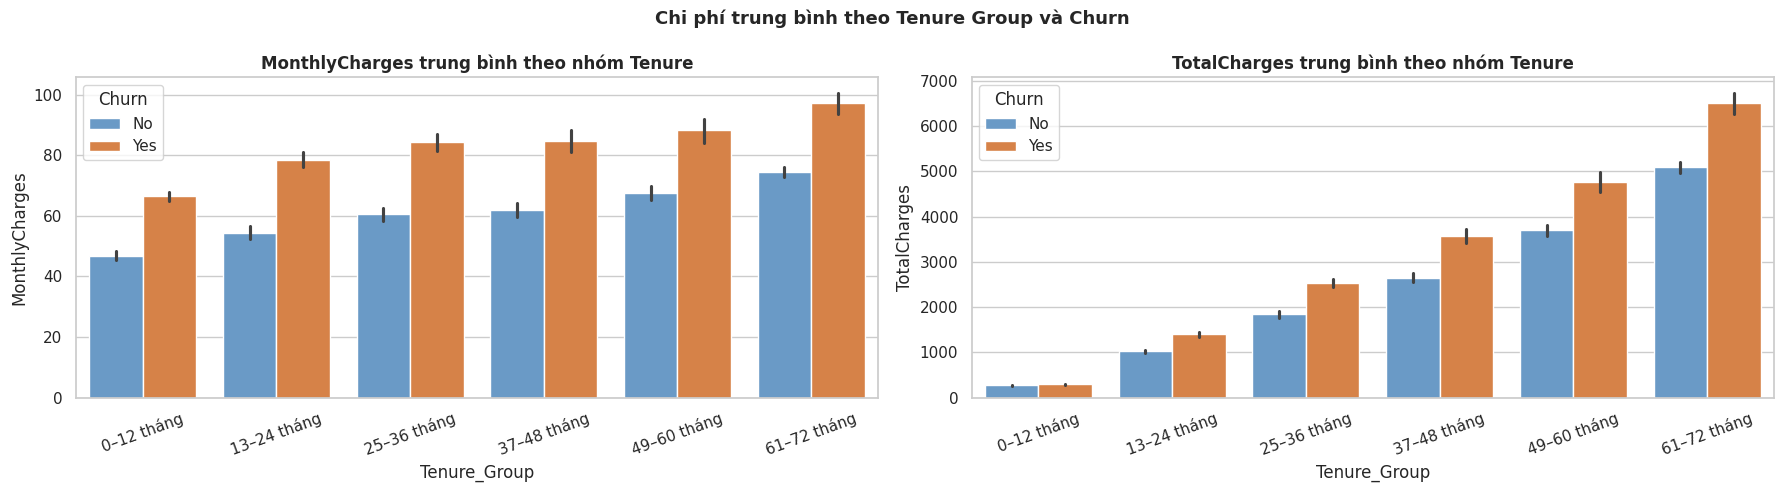

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, col in zip(axes, ["MonthlyCharges", "TotalCharges"]):
    sns.barplot(x="Tenure_Group", y=col, hue="Churn",
                data=data, order=tenure_order, ax=ax,
                palette={"No": "#5B9BD5", "Yes": "#ED7D31"})
    ax.set_title(f"{col} trung bình theo nhóm Tenure", fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Churn")

plt.suptitle("Chi phí trung bình theo Tenure Group và Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Nhận xét:** Ở tất cả nhóm tenure, khách churn đều có `MonthlyCharges` cao hơn nhóm ở lại.  
Điều này củng cố giả thuyết: **phí cao + tenure thấp = tổ hợp rủi ro churn mạnh nhất**.  
Với `TotalCharges`, khoảng cách giữa 2 nhóm thu hẹp dần theo thời gian — khách ở lại lâu tích lũy tổng phí cao hơn.


In [10]:
data = data.drop(columns=["Tenure_Group"], errors="ignore")

### 6.5 Ma trận tương quan — biến số

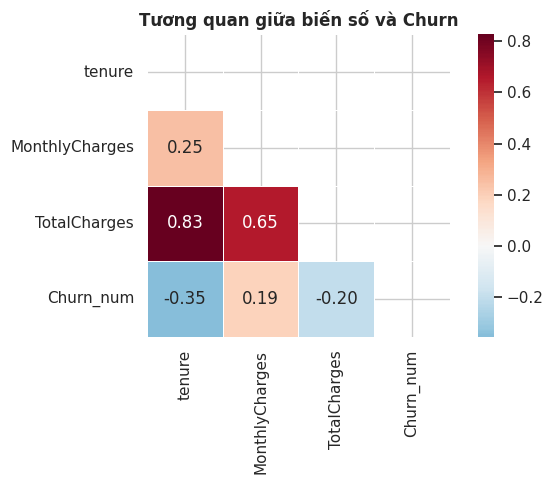

In [11]:
# Tạo biến Churn_num để đưa vào heatmap
corr_df = data[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["Churn_num"] = (data["Churn"] == "Yes").astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, mask=mask, square=True, linewidths=0.5)
ax.set_title("Tương quan giữa biến số và Churn", fontweight="bold")
plt.tight_layout()
plt.show()


**Nhận xét tương quan:**

- **`TotalCharges` và `tenure`** có tương quan rất cao (~0.83) — điều này dễ hiểu vì tổng phí
  tích lũy theo thời gian sử dụng dịch vụ.
- **`TotalCharges` và `MonthlyCharges`** cũng tương quan đáng kể (~0.65).
- **`Churn_num`** tương quan âm với `tenure` (-0.35) → khách hàng có tenure ngắn dễ churn hơn.
- **`Churn_num`** tương quan dương với `MonthlyCharges` (+0.19) → phí cao đi kèm với khả năng churn cao hơn.

> **Lưu ý đa cộng tuyến (multicollinearity):** `TotalCharges ≈ tenure × MonthlyCharges`.
> Các mô hình cây (Random Forest) xử lý tốt điều này;
> với Logistic Regression, nên cân nhắc loại bớt `TotalCharges` hoặc dùng regularization mạnh.




## 8. Chia tập Train / Test  <a id='9-tts'></a>

**Nguyên tắc quan trọng:** Toàn bộ preprocessing (encoding, scaling) phải được **fit chỉ trên
tập train** và **transform riêng rẽ** lên tập test.  
Nếu fit trên toàn bộ dataset trước khi split → **data leakage** → đánh giá mô hình bị lạc quan sai.

**Quy trình thực hiện trong cell dưới:**
1. Tách `X` (đặc trưng) và `y` (nhãn `Churn`).
2. Chia 80/20 — stratify theo `y` để giữ tỷ lệ class giữa train và test.
3. One-hot encode các cột object (`get_dummies`, `drop_first=True`).
4. Căn chỉnh cột giữa train và test (`align`) để tránh lệch sau encode.
5. Scale bằng `StandardScaler` — fit trên train, transform cả hai.

In [12]:
# 2) Tách X, y
X = data.drop("Churn", axis=1)
y = data["Churn"].map({"No": 0, "Yes": 1})

# 3) Chia train/test trước
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) One-hot encode cho các cột object trong X
cat_cols = X_train.select_dtypes(include="object").columns

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# 5) Căn 2 tập cho cùng số cột
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# 6) Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("X_train_sc:", X_train_sc.shape)
print("X_test_sc :", X_test_sc.shape)

X_train: (5625, 30)
X_test : (1407, 30)
X_train_sc: (5625, 30)
X_test_sc : (1407, 30)


## 9. Cấu hình & Huấn luyện mô hình
Bốn mô hình được huấn luyện và tối ưu siêu tham số bằng **`GridSearchCV` (5-fold, scoring=`recall`)**:

| Mô hình | Lý do lựa chọn |
|---------|----------------|
| **Logistic Regression** | Baseline tuyến tính, dễ giải thích |
| **KNN** | Không giả định phân phối, phù hợp khám phá |
| **SVM** | Mạnh với biên phi tuyến, hiệu quả cao chiều |
| **Random Forest** | Ensemble mạnh, xử lý tốt đa cộng tuyến & feature importance |

> **Scoring = `recall`**: ưu tiên phát hiện đúng khách churn (giảm False Negative),
> vì chi phí bỏ sót một khách sắp rời đi cao hơn chi phí tiếp cận nhầm một khách trung thành.

In [13]:
models_cfg = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "solver": ["lbfgs", "liblinear"],
            "class_weight": ["balanced"]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 9],
            "weights": ["uniform", "distance"],
        }
    },
    "SVM": {
        "estimator": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "class_weight": ["balanced"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt"],
            "class_weight": ["balanced"]
        }
    }
}

In [14]:
results = {}

for name, cfg in models_cfg.items():
    print(f"{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    gs = GridSearchCV(
        cfg["estimator"],
        cfg["params"],
        scoring="recall",
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train_sc, y_train)

    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test_sc)
    y_train_pred = best_model.predict(X_train_sc)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_pred)

    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test_sc)[:, 1]
    else:
        y_proba = best_model.decision_function(X_test_sc)

    auc = roc_auc_score(y_test, y_proba)

    print(f"  Best params : {gs.best_params_}")
    print(f"  CV recall   : {gs.best_score_:.4f}")
    print(f"  Train acc   : {train_acc:.4f}  |  Test acc : {test_acc:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"  Gap (overfit indicator): {train_acc - test_acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    results[name] = {
        "model": best_model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "cv_acc": gs.best_score_,
        "auc": auc,
        "report": classification_report(
            y_test, y_pred,
            target_names=["No Churn", "Churn"],
            output_dict=True
        ),
    }

  Training: Logistic Regression
  Best params : {'C': 1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
  CV recall   : 0.8033
  Train acc   : 0.7545  |  Test acc : 0.7264
  AUC         : 0.8350
  Gap (overfit indicator): 0.0281

              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

  Training: KNN
  Best params : {'n_neighbors': 9, 'weights': 'uniform'}
  CV recall   : 0.5318
  Train acc   : 0.8165  |  Test acc : 0.7655
  AUC         : 0.7924
  Gap (overfit indicator): 0.0511

              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1033
       Churn       0.56      0.55      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70   


>> Saved: model_report.png


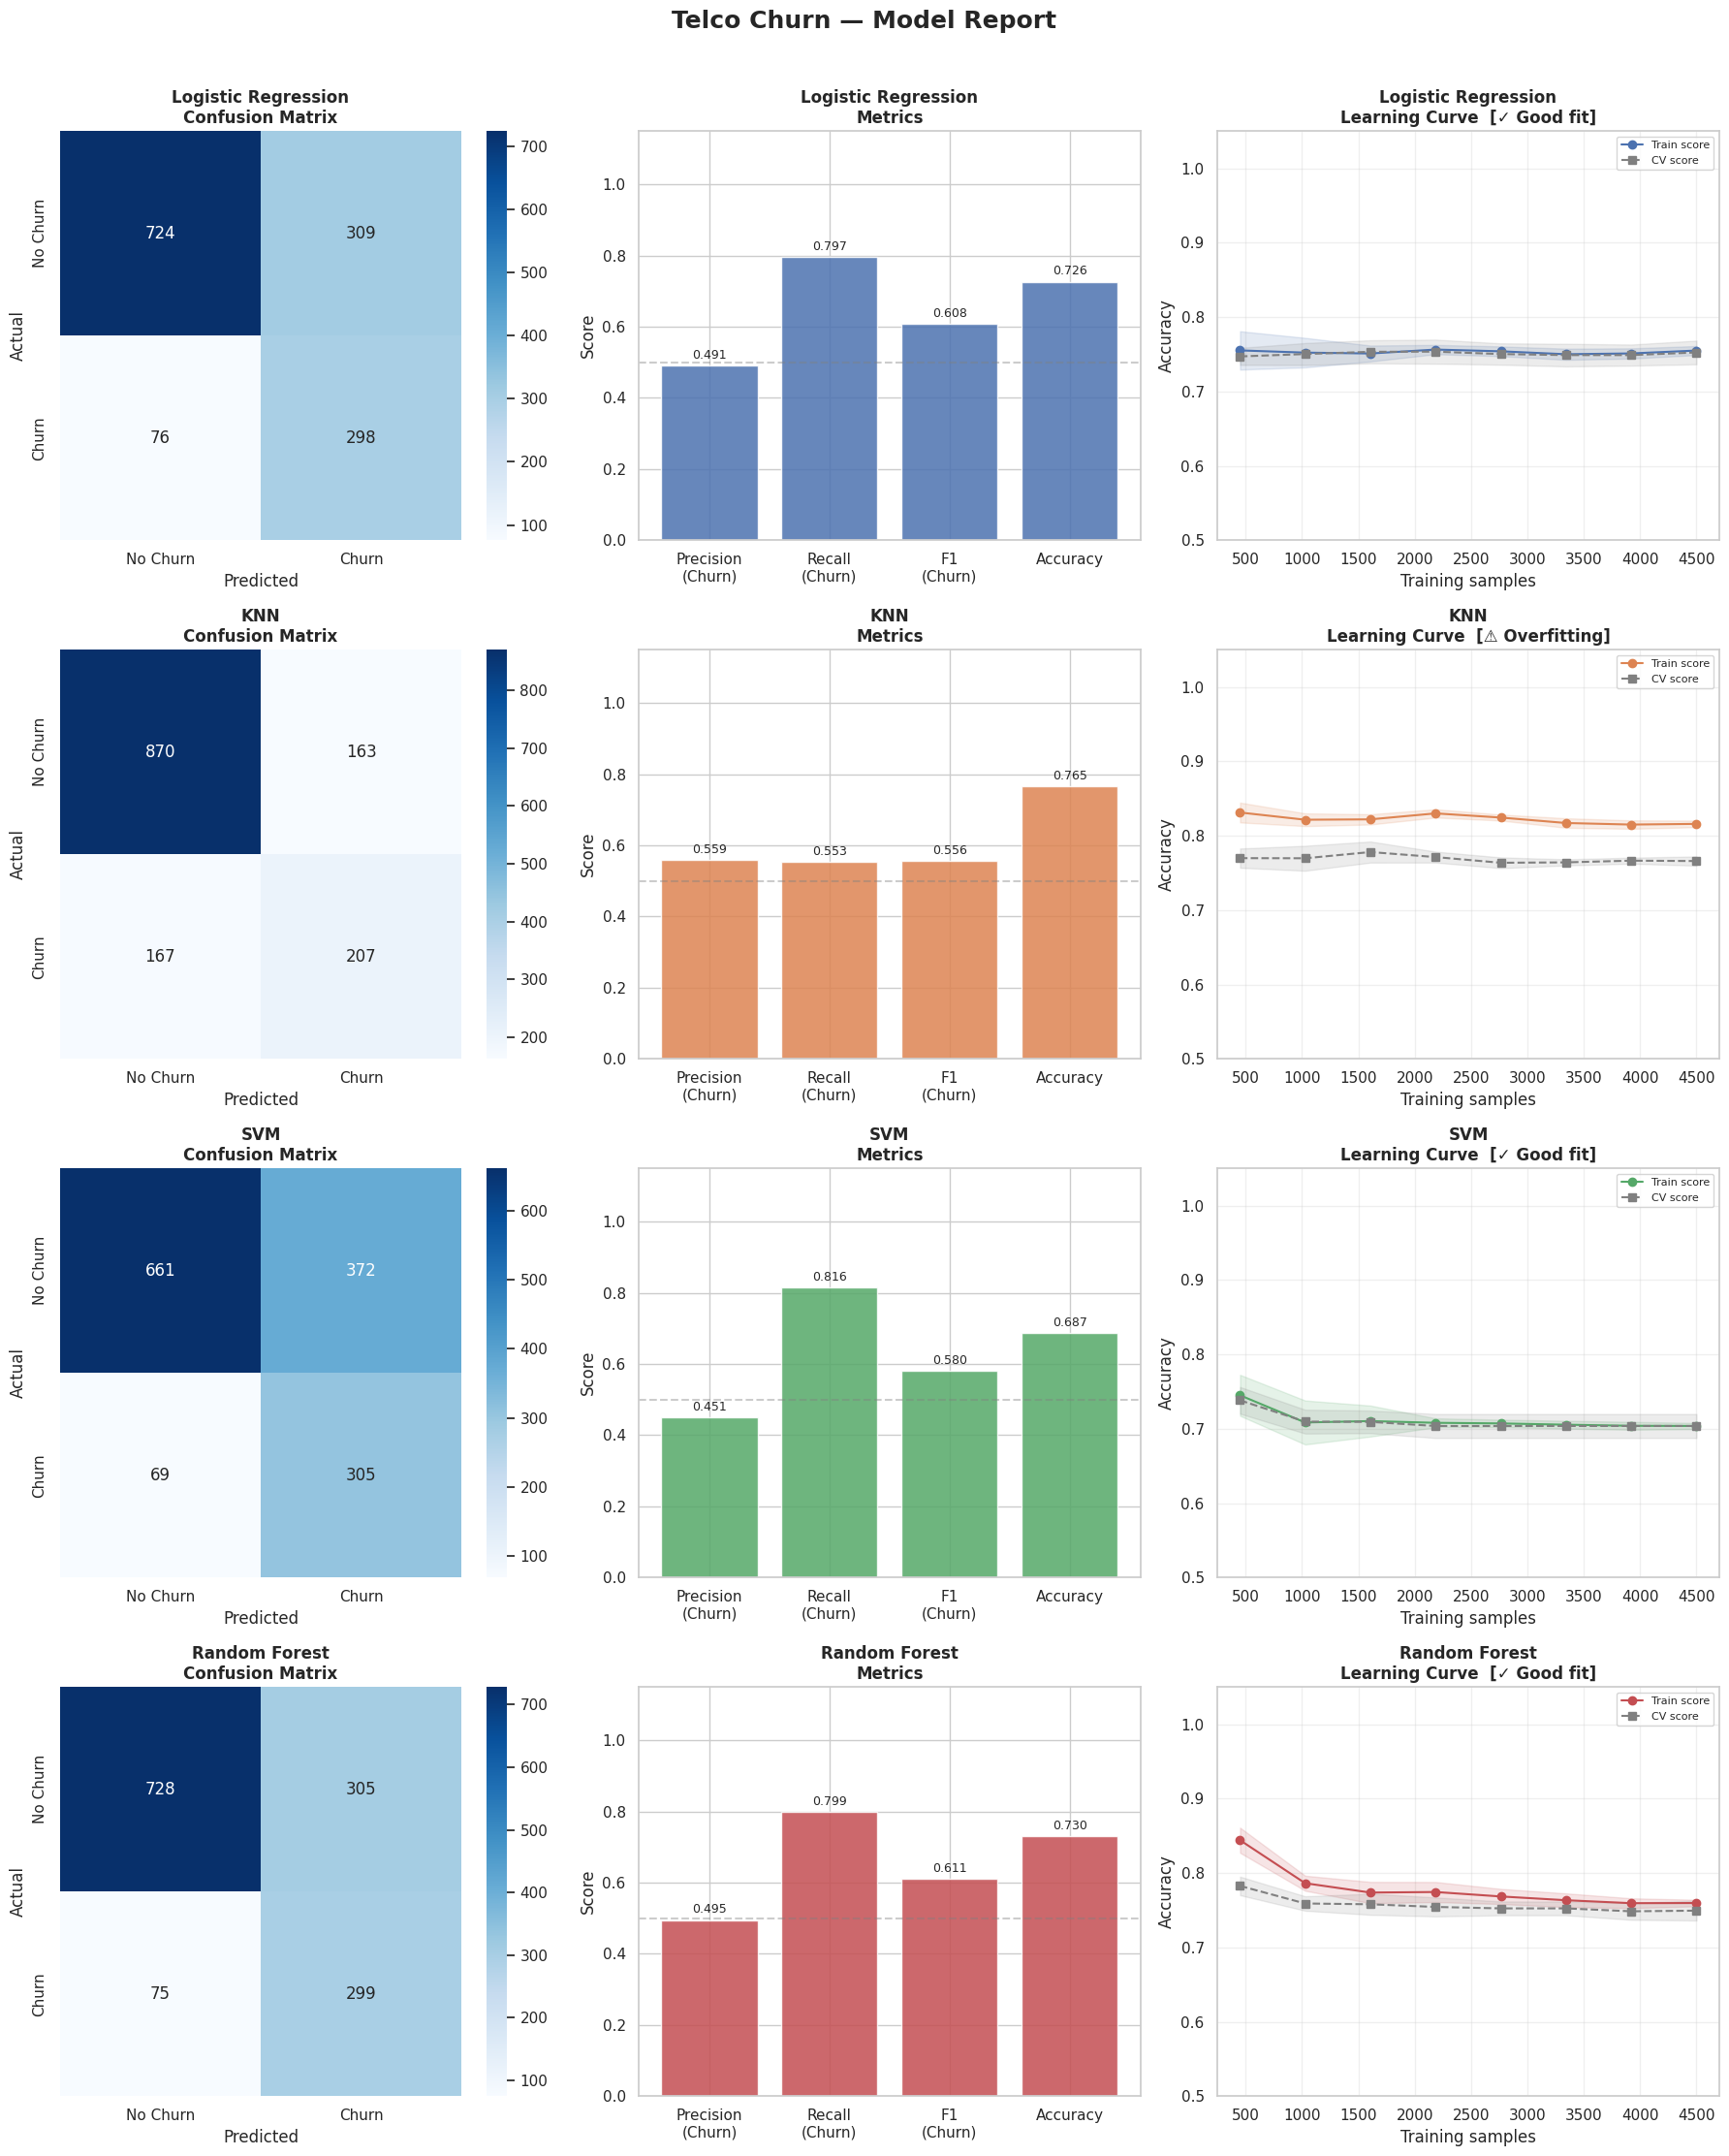

In [15]:
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
model_names = list(results.keys())

fig, axes = plt.subplots(4, 3, figsize=(18, 22))
fig.suptitle("Telco Churn — Model Report", fontsize=18, fontweight="bold", y=1.01)

for row, (name, color) in enumerate(zip(model_names, COLORS)):
    res = results[name]

    # --- Col 0: Confusion Matrix ---
    ax = axes[row, 0]
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"], ax=ax)
    ax.set_title(f"{name}\nConfusion Matrix", fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

    # --- Col 1: Metrics Bar Chart ---
    ax = axes[row, 1]
    rpt = res["report"]
    metrics = {
        "Precision\n(Churn)": rpt["Churn"]["precision"],
        "Recall\n(Churn)":    rpt["Churn"]["recall"],
        "F1\n(Churn)":        rpt["Churn"]["f1-score"],
        "Accuracy":           rpt["accuracy"],
    }
    bars = ax.bar(metrics.keys(), metrics.values(), color=color, alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{name}\nMetrics", fontweight="bold")
    ax.set_ylabel("Score")
    ax.axhline(0.5, linestyle="--", color="gray", alpha=0.4)

    # --- Col 2: Learning Curve (overfitting check) ---
    ax = axes[row, 2]
    train_sizes, train_scores, val_scores = learning_curve(
        res["model"], X_train_sc, y_train,
        cv=5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean,  "o-", color=color,   label="Train score")
    ax.plot(train_sizes, val_mean, "s--", color="gray", label="CV score")
    ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="gray")

    gap = res["train_acc"] - res["test_acc"]
    overfit_label = "⚠ Overfitting" if gap > 0.05 else "✓ Good fit"
    ax.set_title(f"{name}\nLearning Curve  [{overfit_label}]", fontweight="bold")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("model_report.png", dpi=150, bbox_inches="tight")
print("\n>> Saved: model_report.png")
plt.show()

## 10. Kết quả & So sánh các mô hình

In [16]:
print("\n" + "="*55)
print("  SUMMARY TABLE")
print("="*55)
summary = pd.DataFrame({
    name: {
        "CV Accuracy":    f"{res['cv_acc']:.4f}",
        "Train Accuracy": f"{res['train_acc']:.4f}",
        "Test Accuracy":  f"{res['test_acc']:.4f}",
        "Overfit Gap":    f"{res['train_acc'] - res['test_acc']:.4f}",
        "Recall (Churn)": f"{res['report']['Churn']['recall']:.4f}",
        "F1 (Churn)":     f"{res['report']['Churn']['f1-score']:.4f}",
        "AUC": f"{res['auc']:.4f}",
    }
    for name, res in results.items()
}).T
print(summary.to_string())


  SUMMARY TABLE
                    CV Accuracy Train Accuracy Test Accuracy Overfit Gap Recall (Churn) F1 (Churn)     AUC
Logistic Regression      0.8033         0.7545        0.7264      0.0281         0.7968     0.6075  0.8350
KNN                      0.5318         0.8165        0.7655      0.0511         0.5535     0.5565  0.7924
SVM                      0.8368         0.7036        0.6866      0.0171         0.8155     0.5804  0.8115
Random Forest            0.8074         0.7564        0.7299      0.0265         0.7995     0.6115  0.8364


## 11. Lựa chọn mô hình tốt nhất  

Dựa trên bảng so sánh, **Random Forest** được chọn làm mô hình cuối vì:
- **Recall (Churn)** và **AUC** cao nhất trong nhóm.
- **Overfit gap thấp** — mô hình khái quát hóa tốt, không bị overfit nặng.
- Cung cấp **feature importance** — hỗ trợ giải thích và ra quyết định kinh doanh.
- Tích hợp `class_weight='balanced'` xử lý imbalance tốt mà không cần oversample.

In [17]:
best_model_name = "Random Forest"
best_model = results[best_model_name]["model"]

print(f" Mô hình cuối cùng được chọn cho đồ án: {best_model_name}")
print(best_model)

 Mô hình cuối cùng được chọn cho đồ án: Random Forest
RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, random_state=42)


## 12. Phân tích ROC & Confusion Matrix  <a id='16-roc'></a>

Đánh giá toàn diện **Random Forest** trên tập test:
- **Confusion Matrix** — phân tích TP, TN, FP, FN cụ thể.
- **ROC Curve & AUC** — đo khả năng phân tách giữa hai lớp ở mọi ngưỡng.
- **Classification Report** — Precision, Recall, F1 theo từng lớp.

> **Ý nghĩa thực tế của Confusion Matrix:**  
> - *False Negative* (churn thật nhưng đoán không churn) = **tốn kém nhất** — mất khách hàng.  
> - *False Positive* (không churn nhưng đoán churn) = lãng phí chi phí tiếp cận, nhưng chấp nhận được.

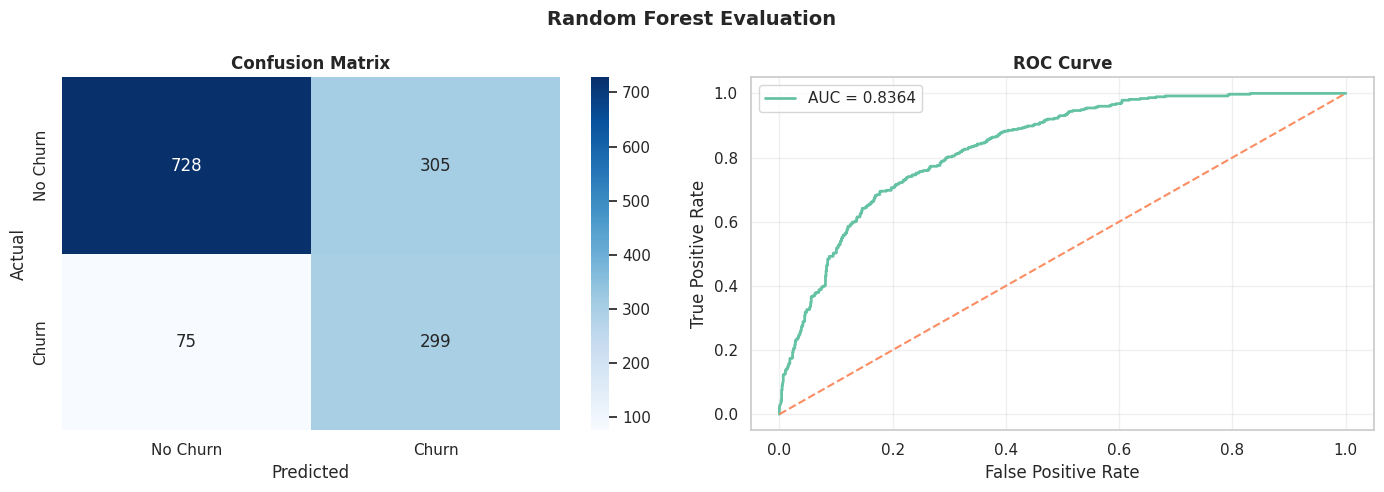

              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

AUC: 0.8364363698484762


In [18]:
rf_pred = results["Random Forest"]["y_pred"]
rf_proba = results["Random Forest"]["y_proba"]

cm = confusion_matrix(y_test, rf_pred)
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

# Tạo figure gồm 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Confusion Matrix =====
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ===== ROC Curve =====
axes[1].plot(fpr, tpr, label=f"AUC = {rf_auc:.4f}", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Random Forest Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# In thêm report
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))
print("AUC:", rf_auc)

## 13. Độ quan trọng đặc trưng  <a id='17-importance'></a>

Random Forest cung cấp **feature importance** dựa trên mức giảm impurity trung bình
(Mean Decrease in Impurity) khi chia tách theo từng đặc trưng.  

> Các đặc trưng có importance cao → đội kinh doanh nên ưu tiên can thiệp vào những yếu tố đó
> để giảm thiểu churn hiệu quả nhất.


,Feature,Importance
1,tenure,0.190280
25,Contract_Two year,0.154318
10,InternetService_Fiber optic,0.087742
3,TotalCharges,0.086161
28,PaymentMethod_Electronic check,0.073311
2,MonthlyCharges,0.065033
24,Contract_One year,0.050667
13,OnlineSecurity_Yes,0.044911
16,DeviceProtection_No internet service,0.034223
12,OnlineSecurity_No internet service,0.032743


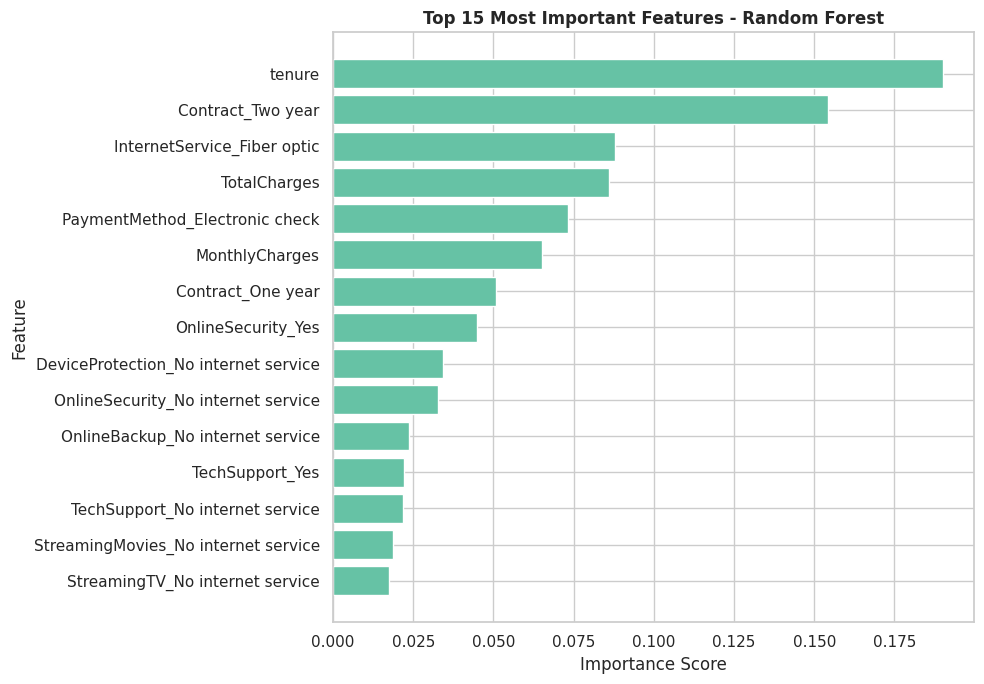

In [19]:
rf_model = results["Random Forest"]["model"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(15))
top_n = 15
top_features = feature_importance.head(top_n).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features - Random Forest", fontweight="bold")
plt.tight_layout()
plt.show()

## 14. Tổng kết Insight & Đề xuất Kinh doanh

### Các insight chính từ phân tích

**1. `tenure` là yếu tố quan trọng nhất trong dự báo churn**  
Biến có độ quan trọng cao nhất trong mô hình Random Forest là `tenure` (importance ≈ 0.19). Điều này cho thấy thời gian gắn bó với dịch vụ là tín hiệu mạnh nhất để phân biệt khách hàng có nguy cơ rời bỏ hay không.  
→ Khách hàng ở giai đoạn đầu vòng đời cần được ưu tiên chăm sóc giữ chân.

---

**2. Loại hợp đồng là đòn bẩy giữ chân rất mạnh**  
`Contract_Two year` và `Contract_One year` đều nằm trong nhóm biến quan trọng nhất. Đặc biệt, hợp đồng 2 năm có mức importance rất cao (≈ 0.154), chỉ đứng sau `tenure`.  
→ Khách hàng gắn với hợp đồng dài hạn có xu hướng ổn định hơn nhiều so với nhóm hợp đồng ngắn hạn.

---

**3. Giá cước là yếu tố ảnh hưởng rõ rệt đến churn**  
`TotalCharges` và `MonthlyCharges` đều thuộc top biến quan trọng. Điều này cho thấy yếu tố chi phí có ảnh hưởng đáng kể đến quyết định rời bỏ.  
→ Không chỉ mức giá, mà cảm nhận về giá trị nhận được so với chi phí mới là yếu tố cần quản trị.

---

**4. Nhóm khách sử dụng Fiber optic có hành vi churn đặc trưng**  
`InternetService_Fiber optic` nằm trong top 3 biến quan trọng nhất (≈ 0.088). Điều này cho thấy nhóm khách này có đặc điểm hành vi khác biệt rõ rệt.  
→ Cần theo dõi riêng trải nghiệm và mức độ hài lòng của nhóm khách Fiber optic.

---

**5. Phương thức thanh toán Electronic check gắn với rủi ro cao hơn**  
`PaymentMethod_Electronic check` xuất hiện trong nhóm biến quan trọng, cho thấy đây là một đặc điểm nhận diện đáng chú ý của nhóm churn.  
→ Có thể phản ánh mức độ gắn bó thấp hơn hoặc trải nghiệm thanh toán chưa tối ưu.

---

**6. Các dịch vụ hỗ trợ giúp tăng khả năng giữ chân**  
Các biến như `OnlineSecurity_Yes`, `TechSupport_Yes` cho thấy khách hàng có sử dụng dịch vụ bổ sung thường có xu hướng gắn bó hơn.  
→ Đây vừa là cơ hội upsell, vừa là cách tăng retention hiệu quả.

---

### Đề xuất hành động kinh doanh

| # | Hành động | Nhóm mục tiêu | Mục tiêu |
|---|-----------|--------------|---------|
| 1 | **Chương trình onboarding & chăm sóc sớm (3–6 tháng đầu)** | Khách tenure thấp | Giảm churn giai đoạn đầu |
| 2 | **Ưu đãi chuyển sang hợp đồng dài hạn** (giảm giá / tặng tháng) | Khách hợp đồng ngắn hạn | Tăng retention |
| 3 | **Tối ưu chiến lược giá & value proposition** | Khách MonthlyCharges cao | Giảm churn do giá |
| 4 | **Theo dõi riêng nhóm Fiber optic** (survey, hỗ trợ nhanh) | Khách Fiber optic | Giảm churn theo phân khúc |
| 5 | **Khuyến khích chuyển phương thức thanh toán** | Khách dùng Electronic check | Giảm churn |
| 6 | **Bundle dịch vụ TechSupport & OnlineSecurity** | Khách chưa dùng add-on | Tăng retention + doanh thu |

---

### Về mô hình và triển khai

Mô hình được chọn là **Random Forest** sau khi so sánh với Logistic Regression, KNN và SVM bằng **GridSearchCV** với tiêu chí tối ưu là **Recall** cho lớp churn.

**Hiệu năng trên tập test:**
- Recall (churn): ~0.80  
- Precision (churn): ~0.50  
- F1-score (churn): ~0.61  
- AUC: ~0.836  

Mô hình ưu tiên phát hiện khách hàng có nguy cơ churn (recall cao), phù hợp với bài toán giữ chân khách hàng trong thực tế kinh doanh.

---

### Gợi ý triển khai thực tế

- Chạy mô hình định kỳ để tạo danh sách khách hàng có nguy cơ churn  
- Ưu tiên can thiệp theo các yếu tố rủi ro chính:
  - tenure thấp  
  - hợp đồng ngắn hạn  
  - Fiber optic  
  - chi phí cao  
  - Electronic check  
- Retrain mô hình định kỳ để tránh data drift  
- Theo dõi song song hiệu quả mô hình và hiệu quả kinh doanh (retention uplift)

---